In [1]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#Loading the Dataset
import pyreadstat

df, meta = pyreadstat.read_sav('track_cycle.sav')
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1665, 80)


In [3]:
# Previewing the Data
print("First 5 rows:")
df.head()

First 5 rows:


,ClientID,CycleNumber,Group,CycleWithPeakorNot,ReproductiveCategory,LengthofCycle,MeanCycleLength,EstimatedDayofOvulation,LengthofLutealPhase,FirstDayofHigh,...,Method,Prevmethod,Methoddate,Whychart,Nextpreg,NextpregM,Spousesame,SpousesameM,Timeattemptpreg,BMI
0,nfp8122,1.0,0.0,1.0,0.0,29.0,27.33,17.0,12.0,12.0,...,9.0,NaN,NaN,2.0,7.0,7.0,1.0,1.0,0.0,21.254724
1,nfp8122,2.0,0.0,1.0,0.0,27.0,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,nfp8122,3.0,0.0,1.0,0.0,29.0,NaN,15.0,14.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,nfp8122,4.0,0.0,1.0,0.0,27.0,NaN,15.0,12.0,13.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,nfp8122,5.0,0.0,1.0,0.0,28.0,NaN,16.0,12.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
#Checking all colomn names
print("\nColumns:")
print(df.columns.tolist())



Columns:
['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'MeanCycleLength', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MeanMensesLength', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'MensesScoreDaySix', 'MensesScoreDaySeven', 'MensesScoreDayEight', 'MensesScoreDayNine', 'MensesScoreDayTen', 'MensesScoreDay11', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay14', 'MensesScoreDay15', 'TotalMensesScore', 'MeanBleedingIntensity', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'PhasesBleeding', 'IntercourseDuringUnusBleed', 'Age', 'AgeM', 'Maristatus', 'MaristatusM', 'Yearsmarried', 'Wedding', 'Religion', 'ReligionM', 'Ethnicity', 'EthnicityM', 'Schoolyears', 'SchoolyearsM', '

In [5]:
#Checking missing values in the dataset
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ClientID                   0
CycleNumber                0
Group                      0
CycleWithPeakorNot         0
ReproductiveCategory       0
                        ... 
NextpregM               1524
Spousesame              1523
SpousesameM             1523
Timeattemptpreg         1523
BMI                     1534
Length: 80, dtype: int64


In [6]:
# Analysing Missing Values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)
print(missing_df)

                            Missing Count  Percentage
MensesScoreDay14                     1664        99.9
MensesScoreDay15                     1664        99.9
MensesScoreDay12                     1664        99.9
MensesScoreDay13                     1664        99.9
MensesScoreDay11                     1663        99.9
...                                   ...         ...
MensesScoreDayTwo                       4         0.2
TotalMensesScore                        4         0.2
NumberofDaysofIntercourse               1         0.1
TotalFertilityFormula                   2         0.1
IntercourseInFertileWindow              1         0.1

[70 rows x 2 columns]


In [7]:
#Categorizing missing values
print("Columns with >50% missing:")
print(missing_df[missing_df['Percentage'] > 50].index.tolist())

print("\nColumns with 5-50% missing:")
print(missing_df[(missing_df['Percentage'] >= 5) & (missing_df['Percentage'] <= 50)].index.tolist())

print("\nColumns with <5% missing:")
print(missing_df[missing_df['Percentage'] < 5].index.tolist())

Columns with >50% missing:
['MensesScoreDay14', 'MensesScoreDay15', 'MensesScoreDay12', 'MensesScoreDay13', 'MensesScoreDay11', 'MensesScoreDayTen', 'Wedding', 'MensesScoreDayNine', 'Prevmethod', 'Methoddate', 'Girls', 'Boys', 'MensesScoreDayEight', 'LivingkidsM', 'IntercourseDuringUnusBleed', 'PhasesBleeding', 'MeanBleedingIntensity', 'BMI', 'Yearsmarried', 'Weight', 'Height', 'SchoolyearsM', 'Schoolyears', 'Miscarriages', 'IncomeM', 'MedvitsM', 'Abortions', 'MeanCycleLength', 'Ethnicity', 'Religion', 'Numberpreg', 'Livingkids', 'Reprocate', 'Age', 'MeanMensesLength', 'MaristatusM', 'AgeM', 'Maristatus', 'Timeattemptpreg', 'Breastfeeding', 'Nextpreg', 'Whychart', 'NextpregM', 'ReligionM', 'EthnicityM', 'Medvits', 'Method', 'Spousesame', 'SpousesameM', 'OccupationM', 'MensesScoreDaySeven', 'MensesScoreDaySix']

Columns with 5-50% missing:
['MensesScoreDayFive', 'FirstDayofHigh', 'LengthofLutealPhase', 'EstimatedDayofOvulation', 'MensesScoreDayFour']

Columns with <5% missing:
['TotalDa

In [8]:
# Dropping columns with >50% missing
cols_to_drop = missing_df[missing_df['Percentage'] > 50].index.tolist()
df = df.drop(columns=cols_to_drop)
print("Shape after dropping high-missing columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping high-missing columns: (1665, 28)
Remaining columns: ['ClientID', 'CycleNumber', 'Group', 'CycleWithPeakorNot', 'ReproductiveCategory', 'LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'FirstDayofHigh', 'TotalNumberofHighDays', 'TotalHighPostPeak', 'TotalNumberofPeakDays', 'TotalDaysofFertility', 'TotalFertilityFormula', 'LengthofMenses', 'MensesScoreDayOne', 'MensesScoreDayTwo', 'MensesScoreDayThree', 'MensesScoreDayFour', 'MensesScoreDayFive', 'TotalMensesScore', 'NumberofDaysofIntercourse', 'IntercourseInFertileWindow', 'UnusualBleeding', 'Medvitexplain', 'Gynosurgeries', 'MedvitexplainM', 'Urosurgeries']


In [10]:
# Filling remaining missing values with median
cols_to_fill = df.columns[df.isnull().any()].tolist()
print("Columns with remaining missing values:", cols_to_fill)

for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after filling:")
print(df.isnull().sum().sum(), "missing values remaining")

Columns with remaining missing values: []

Missing values after filling:
0 missing values remaining


In [11]:
# Checking and removing duplicates
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 13
Shape after removing duplicates: (1652, 28)


In [12]:
#Checking for outliers in key columns
key_cols = ['LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'LengthofMenses']

for col in key_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (lower={lower:.1f}, upper={upper:.1f})")

LengthofCycle: 73 outliers (lower=21.0, upper=37.0)
EstimatedDayofOvulation: 44 outliers (lower=8.0, upper=24.0)
LengthofLutealPhase: 97 outliers (lower=9.0, upper=17.0)
LengthofMenses: 6 outliers (lower=1.0, upper=9.0)


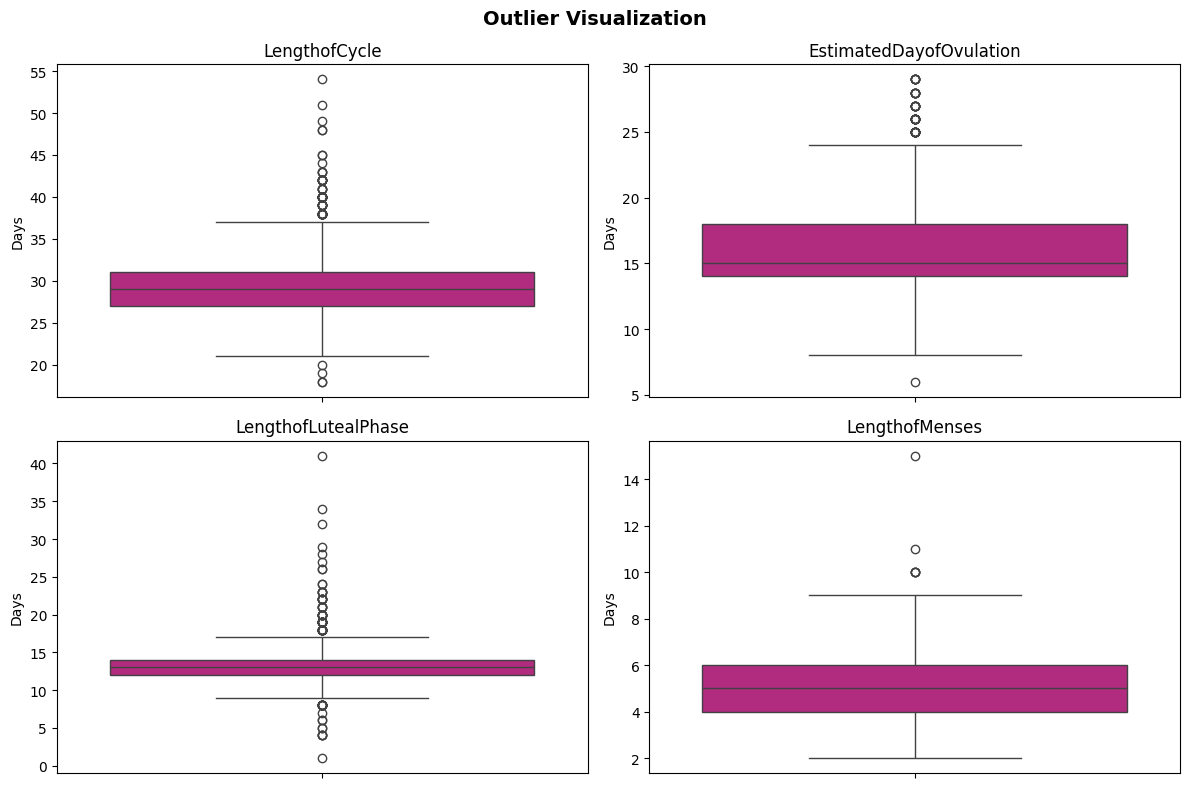

In [13]:
# Visualizing the outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

key_cols = ['LengthofCycle', 'EstimatedDayofOvulation', 'LengthofLutealPhase', 'LengthofMenses']

for ax, col in zip(axes.flatten(), key_cols):
    sns.boxplot(y=df[col], ax=ax, color='mediumvioletred')
    ax.set_title(col)
    ax.set_ylabel('Days')

plt.suptitle('Outlier Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Removing unrealistic outliers
before = df.shape[0]

# Removing unrealistic menses length
df = df[df['LengthofMenses'] <= 9]

# Removing unrealistic luteal phase
df = df[df['LengthofLutealPhase'] >= 2]

after = df.shape[0]
print(f"Rows removed: {before - after}")
print(f"Shape after removing outliers: {df.shape}")

Rows removed: 7
Shape after removing outliers: (1645, 28)


In [15]:
# Checking data types
print("Data Types:")
print(df.dtypes)

Data Types:
ClientID                       object
CycleNumber                   float64
Group                         float64
CycleWithPeakorNot            float64
ReproductiveCategory          float64
LengthofCycle                 float64
EstimatedDayofOvulation       float64
LengthofLutealPhase           float64
FirstDayofHigh                float64
TotalNumberofHighDays         float64
TotalHighPostPeak             float64
TotalNumberofPeakDays         float64
TotalDaysofFertility          float64
TotalFertilityFormula         float64
LengthofMenses                float64
MensesScoreDayOne             float64
MensesScoreDayTwo             float64
MensesScoreDayThree           float64
MensesScoreDayFour            float64
MensesScoreDayFive            float64
TotalMensesScore              float64
NumberofDaysofIntercourse     float64
IntercourseInFertileWindow    float64
UnusualBleeding               float64
Medvitexplain                  object
Gynosurgeries                  object


In [16]:
# Inspecting object columns
obj_cols = ['Medvitexplain', 'Gynosurgeries', 'MedvitexplainM', 'Urosurgeries']
for col in obj_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts())


Medvitexplain unique values:
Medvitexplain
                                                                                 1544
Multivitamin                                                                       18
Prenatal vitamin                                                                    4
Vitamin                                                                             2
prenatal vitamins                                                                   2
                                                                                 ... 
Iron supplement and progesterone from peak day plus 3 to the end of the cycle       1
daily vitamin                                                                       1
multi vitamin                                                                       1
benzaclin - acne topical treatment                                                  1
Multi-Vitamin                                                                       1
Name: coun

In [27]:
# Dropping irrelevant text columns
df = df.drop(columns=['Medvitexplain', 'Gynosurgeries', 'MedvitexplainM', 'Urosurgeries'])
print("Shape after dropping text columns:", df.shape)

Shape after dropping text columns: (1645, 24)


In [19]:
#Final cleaning check
print("Shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)

Shape: (1645, 28)

Missing values: 0

Duplicates: 0

Data types:
ClientID                       object
CycleNumber                   float64
Group                         float64
CycleWithPeakorNot            float64
ReproductiveCategory          float64
LengthofCycle                 float64
EstimatedDayofOvulation       float64
LengthofLutealPhase           float64
FirstDayofHigh                float64
TotalNumberofHighDays         float64
TotalHighPostPeak             float64
TotalNumberofPeakDays         float64
TotalDaysofFertility          float64
TotalFertilityFormula         float64
LengthofMenses                float64
MensesScoreDayOne             float64
MensesScoreDayTwo             float64
MensesScoreDayThree           float64
MensesScoreDayFour            float64
MensesScoreDayFive            float64
TotalMensesScore              float64
NumberofDaysofIntercourse     float64
IntercourseInFertileWindow    float64
UnusualBleeding               float64
Medvitexplain          

In [20]:
#Saving cleaned dataset 
df.to_csv('cycle_data_cleaned.csv', index=False)
print("Cleaned dataset saved as cycle_data_cleaned.csv")
print("Shape:", df.shape)

Cleaned dataset saved as cycle_data_cleaned.csv
Shape: (1645, 28)


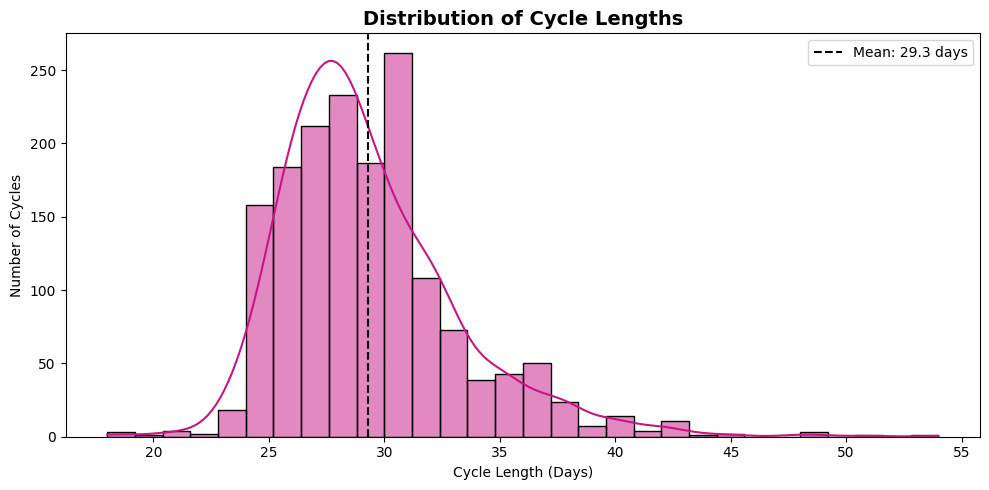

In [26]:
# Distribution of Cycle Lengths(Our key target variable)
plt.figure(figsize=(10, 5))
sns.histplot(df['LengthofCycle'], bins=30, kde=True, color='mediumvioletred')
plt.title('Distribution of Cycle Lengths', fontsize=14, fontweight='bold')
plt.xlabel('Cycle Length (Days)')
plt.ylabel('Number of Cycles')
plt.axvline(df['LengthofCycle'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofCycle"].mean():.1f} days')
plt.legend()
plt.tight_layout()
plt.show()

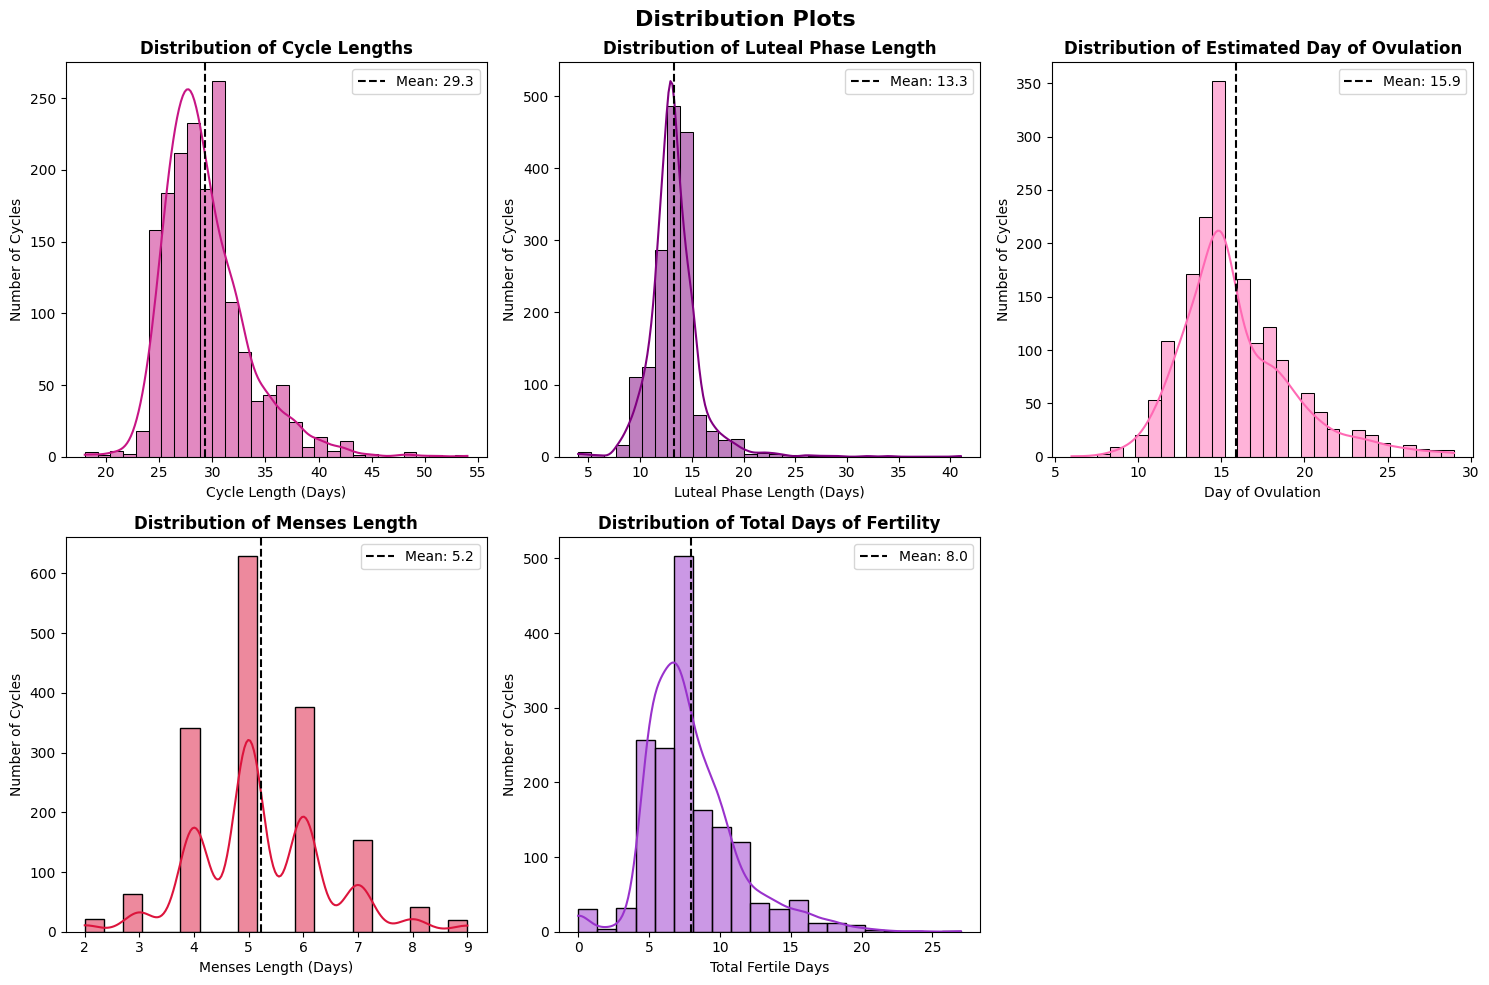

In [ ]:
# DISTRIBUTION PLOTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Cycle Length
sns.histplot(df['LengthofCycle'], bins=30, kde=True, color='mediumvioletred', ax=axes[0,0])
axes[0,0].set_title('Distribution of Cycle Lengths', fontweight='bold')
axes[0,0].set_xlabel('Cycle Length (Days)')
axes[0,0].set_ylabel('Number of Cycles')
axes[0,0].axvline(df['LengthofCycle'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofCycle"].mean():.1f}')
axes[0,0].legend()

# Luteal Phase
sns.histplot(df['LengthofLutealPhase'], bins=30, kde=True, color='purple', ax=axes[0,1])
axes[0,1].set_title('Distribution of Luteal Phase Length', fontweight='bold')
axes[0,1].set_xlabel('Luteal Phase Length (Days)')
axes[0,1].set_ylabel('Number of Cycles')
axes[0,1].axvline(df['LengthofLutealPhase'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofLutealPhase"].mean():.1f}')
axes[0,1].legend()

# Ovulation Day
sns.histplot(df['EstimatedDayofOvulation'], bins=30, kde=True, color='hotpink', ax=axes[0,2])
axes[0,2].set_title('Distribution of Estimated Day of Ovulation', fontweight='bold')
axes[0,2].set_xlabel('Day of Ovulation')
axes[0,2].set_ylabel('Number of Cycles')
axes[0,2].axvline(df['EstimatedDayofOvulation'].mean(), color='black', linestyle='--', label=f'Mean: {df["EstimatedDayofOvulation"].mean():.1f}')
axes[0,2].legend()

# Menses Length
sns.histplot(df['LengthofMenses'], bins=20, kde=True, color='crimson', ax=axes[1,0])
axes[1,0].set_title('Distribution of Menses Length', fontweight='bold')
axes[1,0].set_xlabel('Menses Length (Days)')
axes[1,0].set_ylabel('Number of Cycles')
axes[1,0].axvline(df['LengthofMenses'].mean(), color='black', linestyle='--', label=f'Mean: {df["LengthofMenses"].mean():.1f}')
axes[1,0].legend()

# Total Days of Fertility
sns.histplot(df['TotalDaysofFertility'], bins=20, kde=True, color='darkorchid', ax=axes[1,1])
axes[1,1].set_title('Distribution of Total Days of Fertility', fontweight='bold')
axes[1,1].set_xlabel('Total Fertile Days')
axes[1,1].set_ylabel('Number of Cycles')
axes[1,1].axvline(df['TotalDaysofFertility'].mean(), color='black', linestyle='--', label=f'Mean: {df["TotalDaysofFertility"].mean():.1f}')
axes[1,1].legend()

# Hide empty subplot
axes[1,2].set_visible(False)

plt.suptitle('Distribution Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

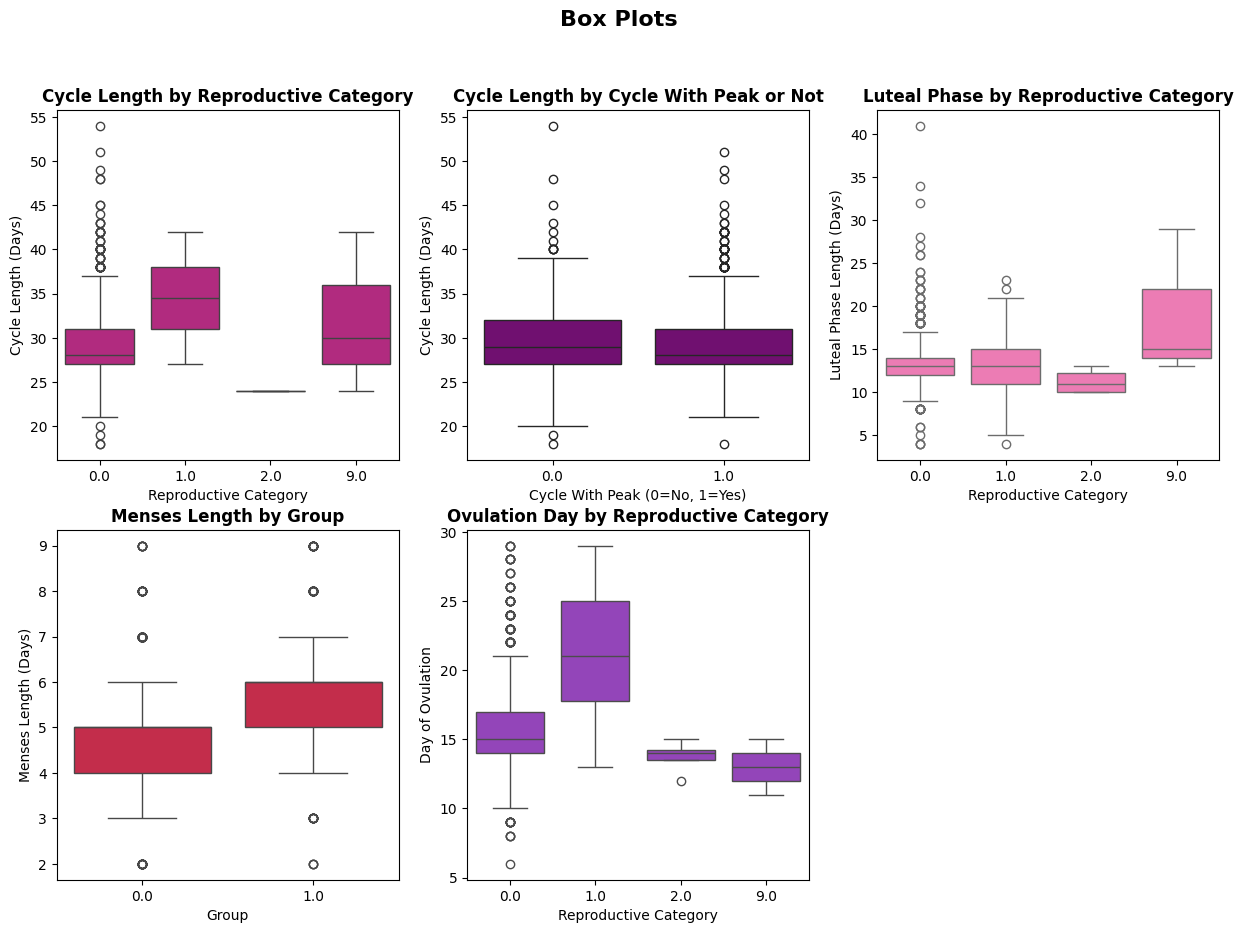

In [ ]:
#BOX PLOTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Cycle Length by Reproductive Category
sns.boxplot(x='ReproductiveCategory', y='LengthofCycle', data=df, color='mediumvioletred', ax=axes[0,0])
axes[0,0].set_title('Cycle Length by Reproductive Category', fontweight='bold')
axes[0,0].set_xlabel('Reproductive Category')
axes[0,0].set_ylabel('Cycle Length (Days)')

# Cycle Length by CycleWithPeakorNot
sns.boxplot(x='CycleWithPeakorNot', y='LengthofCycle', data=df, color='purple', ax=axes[0,1])
axes[0,1].set_title('Cycle Length by Cycle With Peak or Not', fontweight='bold')
axes[0,1].set_xlabel('Cycle With Peak (0=No, 1=Yes)')
axes[0,1].set_ylabel('Cycle Length (Days)')

# Luteal Phase by Reproductive Category
sns.boxplot(x='ReproductiveCategory', y='LengthofLutealPhase', data=df, color='hotpink', ax=axes[0,2])
axes[0,2].set_title('Luteal Phase by Reproductive Category', fontweight='bold')
axes[0,2].set_xlabel('Reproductive Category')
axes[0,2].set_ylabel('Luteal Phase Length (Days)')

# Menses Length by Group
sns.boxplot(x='Group', y='LengthofMenses', data=df, color='crimson', ax=axes[1,0])
axes[1,0].set_title('Menses Length by Group', fontweight='bold')
axes[1,0].set_xlabel('Group')
axes[1,0].set_ylabel('Menses Length (Days)')

# Ovulation Day by Reproductive Category
sns.boxplot(x='ReproductiveCategory', y='EstimatedDayofOvulation', data=df, color='darkorchid', ax=axes[1,1])
axes[1,1].set_title('Ovulation Day by Reproductive Category', fontweight='bold')
axes[1,1].set_xlabel('Reproductive Category')
axes[1,1].set_ylabel('Day of Ovulation')

# Hidng empty subplot
axes[1,2].set_visible(False)

plt.suptitle('Box Plots', fontsize=16, fontweight='bold')
plt.tight_layout

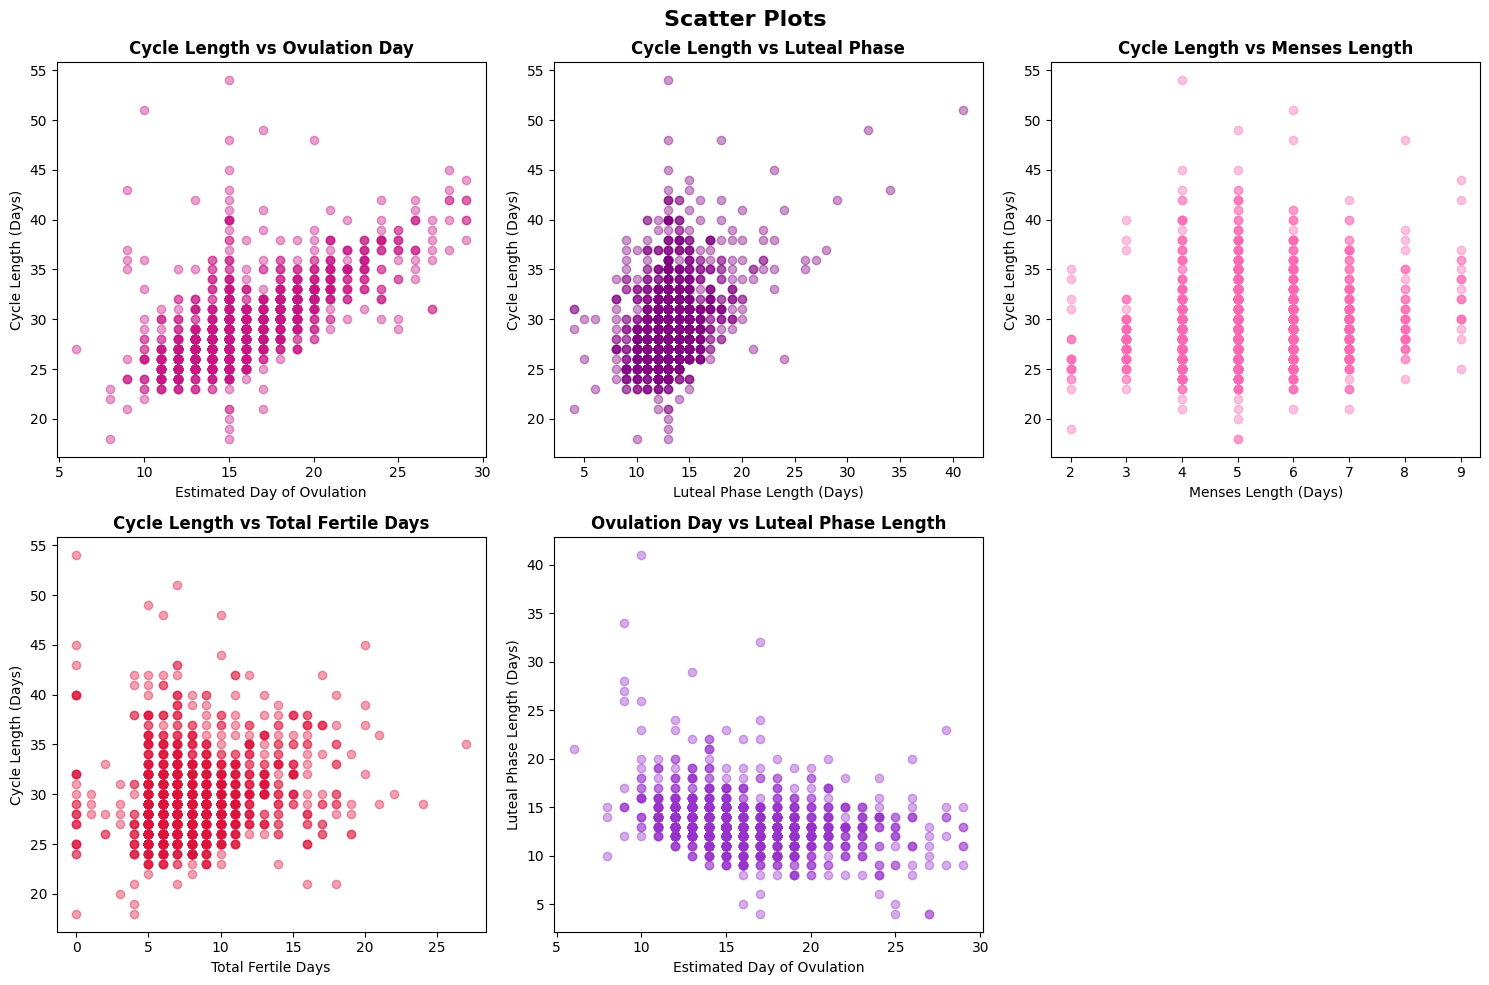

In [29]:
# SCATTER PLOTS
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Cycle Length vs Ovulation Day
axes[0,0].scatter(df['EstimatedDayofOvulation'], df['LengthofCycle'], color='mediumvioletred', alpha=0.4)
axes[0,0].set_title('Cycle Length vs Ovulation Day', fontweight='bold')
axes[0,0].set_xlabel('Estimated Day of Ovulation')
axes[0,0].set_ylabel('Cycle Length (Days)')

# Cycle Length vs Luteal Phase
axes[0,1].scatter(df['LengthofLutealPhase'], df['LengthofCycle'], color='purple', alpha=0.4)
axes[0,1].set_title('Cycle Length vs Luteal Phase', fontweight='bold')
axes[0,1].set_xlabel('Luteal Phase Length (Days)')
axes[0,1].set_ylabel('Cycle Length (Days)')

# Cycle Length vs Menses Length
axes[0,2].scatter(df['LengthofMenses'], df['LengthofCycle'], color='hotpink', alpha=0.4)
axes[0,2].set_title('Cycle Length vs Menses Length', fontweight='bold')
axes[0,2].set_xlabel('Menses Length (Days)')
axes[0,2].set_ylabel('Cycle Length (Days)')

# Cycle Length vs Total Fertile Days
axes[1,0].scatter(df['TotalDaysofFertility'], df['LengthofCycle'], color='crimson', alpha=0.4)
axes[1,0].set_title('Cycle Length vs Total Fertile Days', fontweight='bold')
axes[1,0].set_xlabel('Total Fertile Days')
axes[1,0].set_ylabel('Cycle Length (Days)')

# Ovulation Day vs Luteal Phase
axes[1,1].scatter(df['EstimatedDayofOvulation'], df['LengthofLutealPhase'], color='darkorchid', alpha=0.4)
axes[1,1].set_title('Ovulation Day vs Luteal Phase Length', fontweight='bold')
axes[1,1].set_xlabel('Estimated Day of Ovulation')
axes[1,1].set_ylabel('Luteal Phase Length (Days)')

# Hide empty subplot
axes[1,2].set_visible(False)

plt.suptitle('Scatter Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

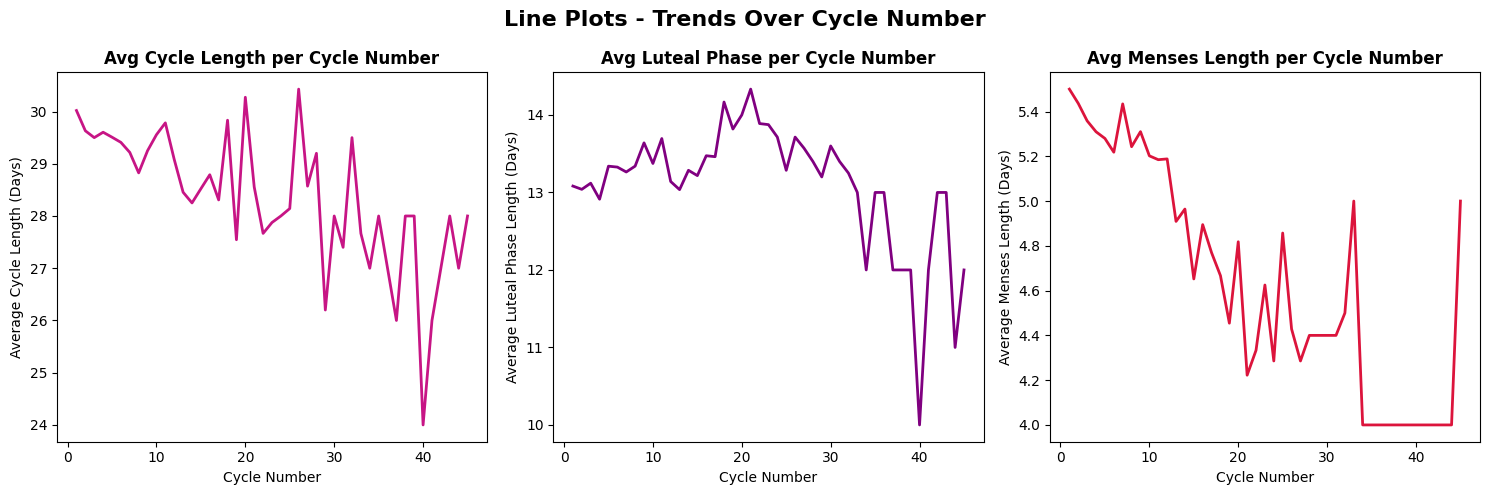

In [ ]:
#LINE PLOTS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Average Cycle Length per Cycle Number
cycle_avg = df.groupby('CycleNumber')['LengthofCycle'].mean()
axes[0].plot(cycle_avg.index, cycle_avg.values, color='mediumvioletred', linewidth=2)
axes[0].set_title('Avg Cycle Length per Cycle Number', fontweight='bold')
axes[0].set_xlabel('Cycle Number')
axes[0].set_ylabel('Average Cycle Length (Days)')

# Average Luteal Phase per Cycle Number
luteal_avg = df.groupby('CycleNumber')['LengthofLutealPhase'].mean()
axes[1].plot(luteal_avg.index, luteal_avg.values, color='purple', linewidth=2)
axes[1].set_title('Avg Luteal Phase per Cycle Number', fontweight='bold')
axes[1].set_xlabel('Cycle Number')
axes[1].set_ylabel('Average Luteal Phase Length (Days)')

# Average Menses Length per Cycle Number
menses_avg = df.groupby('CycleNumber')['LengthofMenses'].mean()
axes[2].plot(menses_avg.index, menses_avg.values, color='crimson', linewidth=2)
axes[2].set_title('Avg Menses Length per Cycle Number', fontweight='bold')
axes[2].set_xlabel('Cycle Number')
axes[2].set_ylabel('Average Menses Length (Days)')

plt.suptitle('Line Plots - Trends Over Cycle Number', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

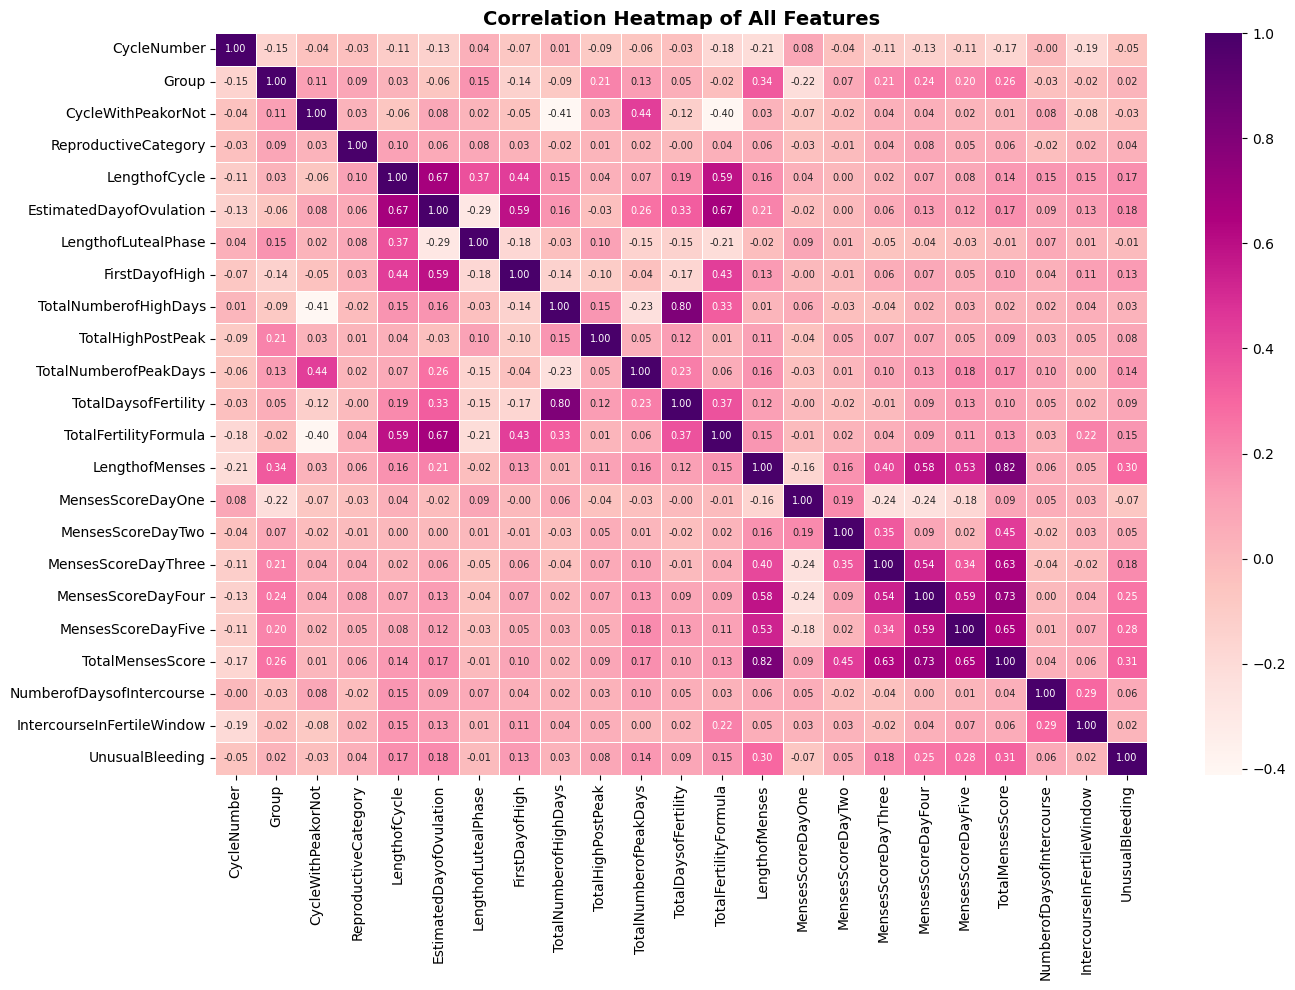

In [ ]:
#CORRELATION HEATMAP
plt.figure(figsize=(14, 10))
corr = df.drop(columns=['ClientID']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdPu', linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap of All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

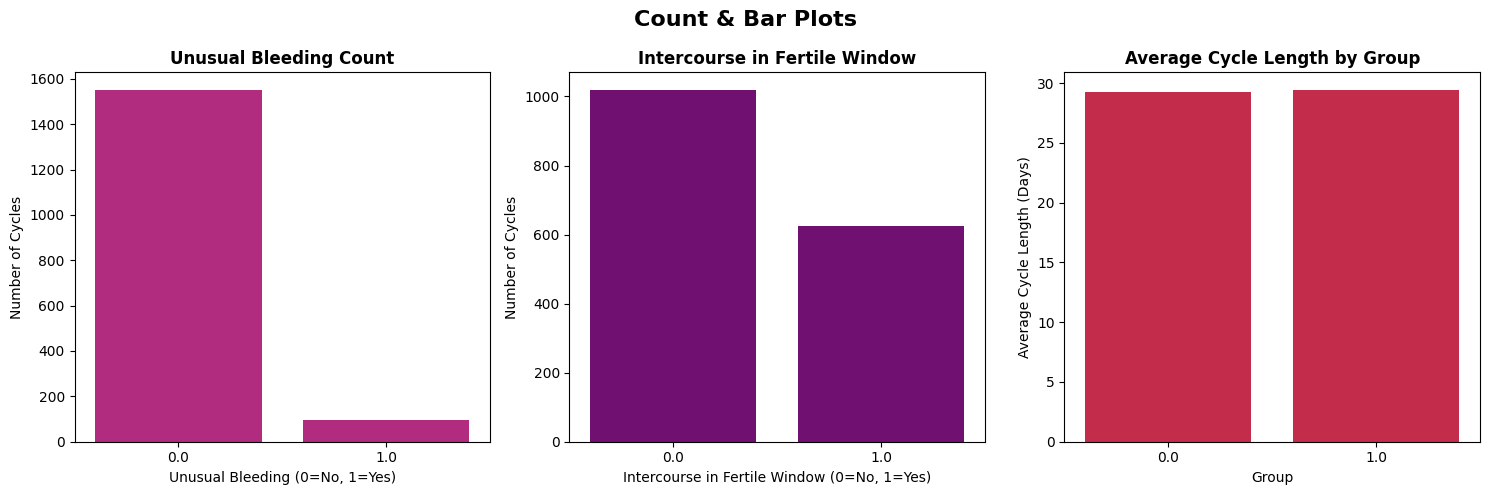

In [30]:
# COUNT & BAR PLOTS
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Unusual Bleeding Count
sns.countplot(x='UnusualBleeding', data=df, color='mediumvioletred', ax=axes[0])
axes[0].set_title('Unusual Bleeding Count', fontweight='bold')
axes[0].set_xlabel('Unusual Bleeding (0=No, 1=Yes)')
axes[0].set_ylabel('Number of Cycles')

# Intercourse in Fertile Window Count
sns.countplot(x='IntercourseInFertileWindow', data=df, color='purple', ax=axes[1])
axes[1].set_title('Intercourse in Fertile Window', fontweight='bold')
axes[1].set_xlabel('Intercourse in Fertile Window (0=No, 1=Yes)')
axes[1].set_ylabel('Number of Cycles')

# Average Cycle Length by Group
group_avg = df.groupby('Group')['LengthofCycle'].mean().reset_index()
sns.barplot(x='Group', y='LengthofCycle', data=group_avg, color='crimson', ax=axes[2])
axes[2].set_title('Average Cycle Length by Group', fontweight='bold')
axes[2].set_xlabel('Group')
axes[2].set_ylabel('Average Cycle Length (Days)')

plt.suptitle('Count & Bar Plots', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

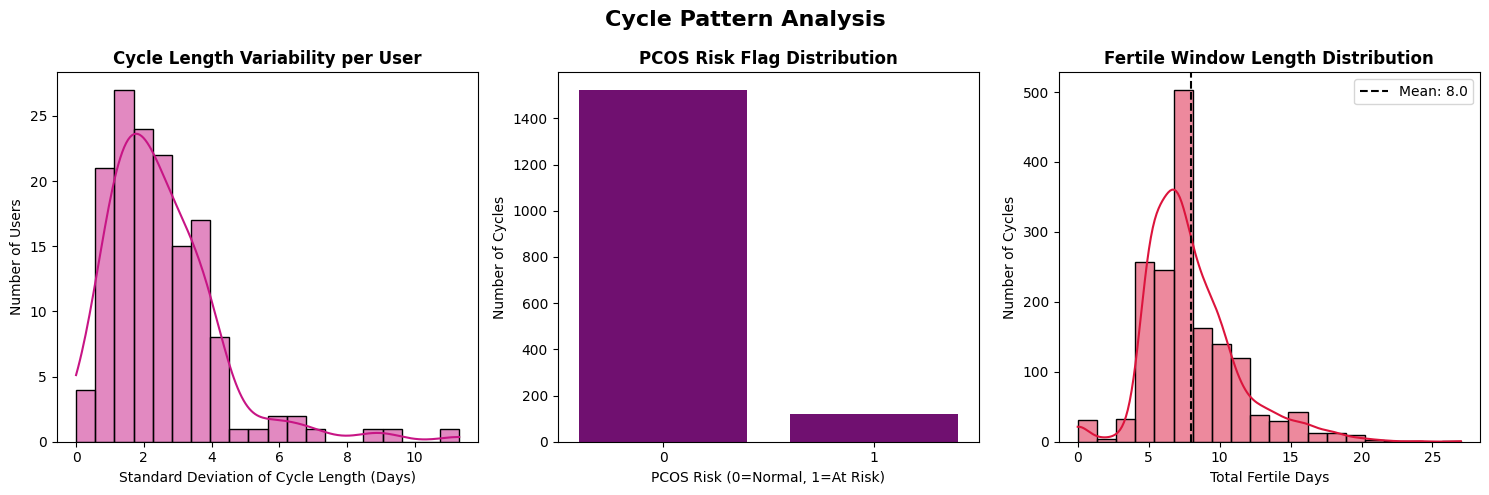

In [31]:
# Cycle Pattern Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cycle Length Variability per User
cycle_std = df.groupby('ClientID')['LengthofCycle'].std().dropna()
sns.histplot(cycle_std, bins=20, kde=True, color='mediumvioletred', ax=axes[0])
axes[0].set_title('Cycle Length Variability per User', fontweight='bold')
axes[0].set_xlabel('Standard Deviation of Cycle Length (Days)')
axes[0].set_ylabel('Number of Users')

# PCOS Risk Flag Distribution
df['PCOS_Risk'] = df['LengthofCycle'].apply(lambda x: 1 if x < 21 or x > 35 else 0)
sns.countplot(x='PCOS_Risk', data=df, color='purple', ax=axes[1])
axes[1].set_title('PCOS Risk Flag Distribution', fontweight='bold')
axes[1].set_xlabel('PCOS Risk (0=Normal, 1=At Risk)')
axes[1].set_ylabel('Number of Cycles')

# 25. Fertile Window Length Distribution
sns.histplot(df['TotalDaysofFertility'], bins=20, kde=True, color='crimson', ax=axes[2])
axes[2].set_title('Fertile Window Length Distribution', fontweight='bold')
axes[2].set_xlabel('Total Fertile Days')
axes[2].set_ylabel('Number of Cycles')
axes[2].axvline(df['TotalDaysofFertility'].mean(), color='black', linestyle='--', label=f'Mean: {df["TotalDaysofFertility"].mean():.1f}')
axes[2].legend()

plt.suptitle('Cycle Pattern Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()